# Environment

In [1]:
import os
os.chdir("..")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

from src.utils.map import SYMPTOM_MAP

In [3]:
LABEL_COLUMNS = list(SYMPTOM_MAP.values())

## Data Load

In [4]:
df_base = pd.read_csv("./data/processed/amive.csv")
df_lex = pd.read_csv("./data/features/amive_lex.csv")
df_ge = pd.read_csv("./data/features/amive_ge.csv")
df_gep = pd.read_csv("./data/features/amive_gep.csv")

# Feature Selection

## Mutual Information

In [10]:
feature_sets = {
    "lex": df_lex,
    "ge": df_ge,
    "gep": df_gep,
}

df_all = df_base.copy()
for df_feat in feature_sets.values():
    df_all = df_all.merge(df_feat, on="DOCNO")

feature_cols = [c for c in df_all.columns if c not in ["TEXT", "DOCNO"] + LABEL_COLUMNS]
X = df_all[feature_cols].fillna(0).values
y = df_all[LABEL_COLUMNS].values

scores = np.zeros(len(feature_cols))
for i in range(y.shape[1]):
    scores += mutual_info_classif(X, y[:, i], random_state=21)

ranking = pd.Series(scores, index=feature_cols).sort_values(ascending=False)
display(ranking)

luto               0.285632
decepção           0.267603
medo               0.267381
remorso            0.261655
tristeza           0.239569
nervosismo         0.235256
aborrecimento      0.218934
raiva              0.216595
desejo             0.154871
entusiasmo         0.153981
confusão           0.144994
surpresa           0.143628
desaprovação       0.135936
constrangimento    0.132904
alívio             0.126806
neutro             0.121651
realização         0.120051
alegria            0.116449
orgulho            0.116219
feat_neg_ratio     0.114114
nojo               0.108365
gratidão           0.091164
amor               0.090686
otimismo           0.090214
aprovação          0.089646
diversão           0.080141
curiosidade        0.075404
zelo               0.070325
feat_nto_ratio     0.063787
admiração          0.060835
polarity           0.060797
feat_pos_ratio     0.042245
dtype: float64

## Elbow Curve

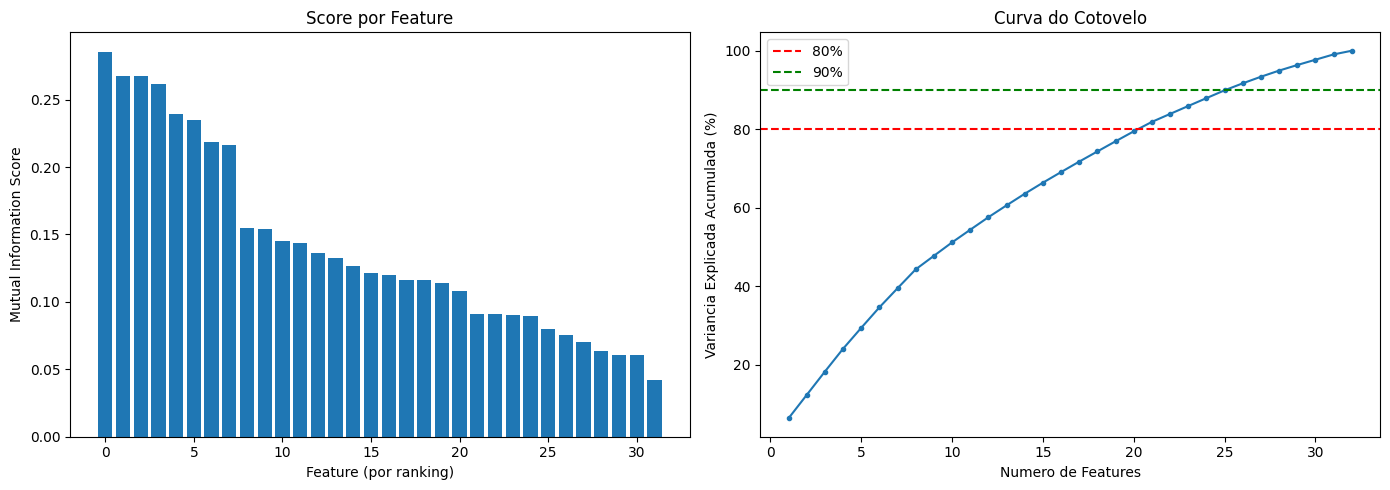

80% da informacao: 21 features
90% da informacao: 26 features
95% da informacao: 29 features


In [11]:
scores_sorted = ranking.values
scores_cumsum = np.cumsum(scores_sorted) / np.sum(scores_sorted) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(len(scores_sorted)), scores_sorted)
ax1.set_xlabel("Feature (por ranking)")
ax1.set_ylabel("Mutual Information Score")
ax1.set_title("Score por Feature")

ax2.plot(range(1, len(scores_cumsum) + 1), scores_cumsum, marker="o", markersize=3)
ax2.axhline(y=80, color="r", linestyle="--", label="80%")
ax2.axhline(y=90, color="g", linestyle="--", label="90%")
ax2.set_xlabel("Numero de Features")
ax2.set_ylabel("Variancia Explicada Acumulada (%)")
ax2.set_title("Curva do Cotovelo")
ax2.legend()

plt.tight_layout()
plt.show()

for threshold in [80, 90, 95]:
    n = np.argmax(scores_cumsum >= threshold) + 1
    print(f"{threshold}% da informacao: {n} features")

## Selected Features

In [12]:
n_features = np.argmax(scores_cumsum >= 80) + 1
selected_features = ranking.index[:n_features].tolist()

In [13]:
selected_features

['luto',
 'decepção',
 'medo',
 'remorso',
 'tristeza',
 'nervosismo',
 'aborrecimento',
 'raiva',
 'desejo',
 'entusiasmo',
 'confusão',
 'surpresa',
 'desaprovação',
 'constrangimento',
 'alívio',
 'neutro',
 'realização',
 'alegria',
 'orgulho',
 'feat_neg_ratio',
 'nojo']

In [16]:
df_selected = df_all[["DOCNO"] + selected_features]

In [18]:
df_selected.to_csv("./data/features/amive_mi80.csv", index=False)